In [1]:
!pip install GitPython

In [2]:
import os
import re
import shutil
import pandas as pd
from git import Repo, GitCommandError

# paths to download  CHANGE HERE O_0
base_dir = "/home/lalithamsh-k/ssdpy3/Q1/repos"
results_dir = "/home/lalithamsh-k/ssdpy3/Q1/results"
os.makedirs(base_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# Repos
repo_links = [
    "https://github.com/abhinavborah/vidyavichara-team25",
    "https://github.com/Sahoo-Achyutananda/vidya-vichar/tree/test",
    "https://github.com/geethamGT3RS/VidyaVichar",
    "https://github.com/IIITH-2025-27/VidyaVichar",
    "https://github.com/PrathyushaKalluri/VidyaVichar_Team33.git",
    "https://github.com/Caerus256/VidyaVichars",
    "https://github.com/Rajkjain03/VidyaVichar-Classroom-Q-A-sticky-board",
    "https://github.com/nradhakrishna/vidya-vichaar",
    "https://github.com/leocodeio/vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon",
    "https://github.com/anudeepbutha/VidyaVichar_main",
    "https://github.com/a-n-u-p-a-m/Group_27_SSD_MID_LAB",
    "https://github.com/incredibleharsh021/Vidya-Vichar.git",
    "https://github.com/Ishaan-Giri/VidyaVichar.git",
    "https://github.com/aayush18602/SSD_MidSem/tree/kavan1",
    "https://github.com/guptamanali0/VidhyaVichaar.git",
    "https://github.com/PranjalSK03/Vidya_Vichar_group5.git",
    "https://github.com/Yogesh-Narasimha/SSD_MID_group_21.git",
    "https://github.com/Sankalp0109/VidhyaVichar",
    "https://github.com/SSD-MidSem-Hackathon/VidhyaVichar",
    "https://github.com/shadesin/VidyaVichar",
    "https://github.com/sumitgk2003/VidyaVichar_SSD_M25_G20",
]

# clone repos 
cloned_repos = []
failed_repos = []

for link in repo_links:
    try:
        parts = link.rstrip("/").split("/")
        if len(parts) < 2:
            print(f"Invalid link: {link}")
            continue
        
        user = parts[-2]
        repo = parts[-1].replace(".git", "")
        folder_name = f"{user}_{repo}"
        dest_path = os.path.join(base_dir, folder_name)
        
        if os.path.exists(dest_path):
            print(f"{folder_name} already exists, skipping.")
            cloned_repos.append(dest_path)
            continue
            
        print(f"Cloning {folder_name} ...")
        Repo.clone_from(link, dest_path)
        cloned_repos.append(dest_path)
        
    except GitCommandError as e:
        print(f"❌ Failed to clone {link}: {e}")
        failed_repos.append(link)

print(f"\n✅ Cloned {len(cloned_repos)} repositories")
if failed_repos:
    print("⚠️ Failed to clone the following:")
    for repo in failed_repos:
        print("  -", repo)

abhinavborah_vidyavichara-team25 already exists, skipping.
Cloning tree_test ...
❌ Failed to clone https://github.com/Sahoo-Achyutananda/vidya-vichar/tree/test: Cmd('git') failed due to: exit code(128)
  cmdline: git clone -v -- https://github.com/Sahoo-Achyutananda/vidya-vichar/tree/test /home/lalithamsh-k/ssdpy3/Q1/repos/tree_test
  stderr: 'Cloning into '/home/lalithamsh-k/ssdpy3/Q1/repos/tree_test'...
fatal: repository 'https://github.com/Sahoo-Achyutananda/vidya-vichar/tree/test/' not found
'
geethamGT3RS_VidyaVichar already exists, skipping.
IIITH-2025-27_VidyaVichar already exists, skipping.
PrathyushaKalluri_VidyaVichar_Team33 already exists, skipping.
Cloning Caerus256_VidyaVichars ...
❌ Failed to clone https://github.com/Caerus256/VidyaVichars: Cmd('git') failed due to: exit code(128)
  cmdline: git clone -v -- https://github.com/Caerus256/VidyaVichars /home/lalithamsh-k/ssdpy3/Q1/repos/Caerus256_VidyaVichars
  stderr: 'Cloning into '/home/lalithamsh-k/ssdpy3/Q1/repos/Caerus2

In [3]:
def count_loc(code: str) -> int:
    """Count non-empty, non-comment lines of code."""
    # Remove multi-line comments first
    code = re.sub(r'/\*[\s\S]*?\*/', '', code)
    
    lines = code.split('\n')
    loc = 0
    
    for line in lines: #remove space, tabs, comments
        line = re.sub(r'//.*', '', line)
        line = line.strip()
        if line:
            loc += 1
    
    return loc


def count_react_components(code: str) -> int:
    """Count React components (both class and functional)."""
    count = 0
    
    # Class components: class X extends React.Component or Component
    count += len(re.findall(r'class\s+\w+\s+extends\s+(React\.)?Component', code))
    
    # Functional components with JSX return
    # Pattern: function ComponentName() { ... return (...) or return 
    count += len(re.findall(r'function\s+[A-Z]\w*\s*\([^)]*\)\s*\{[^}]*return\s*[\(<]', code))
    
    # Arrow function components: const Component = () => 
    count += len(re.findall(r'const\s+[A-Z]\w*\s*=\s*\([^)]*\)\s*=>', code))
    
    # Alternative: export default function Component
    count += len(re.findall(r'export\s+default\s+function\s+[A-Z]\w*', code))
    
    return count


def collect_files(repo_path: str, extensions=(".js", ".jsx", ".json", ".css")):
    """Recursively collect all source files from a repository."""
    collected = []
    # Exclude common directories that shouldn't be counted
    exclude_dirs = {'node_modules', '.git', 'build', 'dist', 'coverage', '.next'}
    
    for root, dirs, files in os.walk(repo_path):
        # Remove excluded directories from search
        dirs[:] = [d for d in dirs if d not in exclude_dirs]
        
        for file in files:
            if file.endswith(extensions):
                collected.append(os.path.join(root, file))
    return collected

In [4]:
def summarize_repo(repo_path: str):   
    js_files = collect_files(repo_path)
    loc = react_comp = express_routes = models = 0
    
    for file_path in js_files:
        try:
            with open(file_path, encoding="utf-8", errors="ignore") as f:
                code = f.read()
            
            # Count LOC on original code (with comments removed)
            loc += count_loc(code)
            
            # Only analyze JS/JSX files for framework-specific patterns
            if file_path.endswith(('.js', '.jsx')):
                react_comp += count_react_components(code)
                express_routes += len(re.findall(r'(app|router)\.(get|post|put|delete|patch)\s*\(', code))
                models += len(re.findall(r'mongoose\.model\s*\(', code))
                
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    folder_count = sum(len(dirs) for _, dirs, _ in os.walk(repo_path))
    
    return {
        "Project": os.path.basename(repo_path),
        "Folders": folder_count,
        "Files": len(js_files),
        "LOC": loc,
        "React_Components": react_comp,
        "Express_Routes": express_routes,
        "Mongoose_Models": models
    }


# Summarize all repos
summary_data = []
for repo_path in cloned_repos:
    print(f"Summarizing {os.path.basename(repo_path)} ...")
    summary_data.append(summarize_repo(repo_path))

df = pd.DataFrame(summary_data)
summary_path = os.path.join(results_dir, "summaries.csv")
df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")


Summarizing abhinavborah_vidyavichara-team25 ...
Summarizing geethamGT3RS_VidyaVichar ...
Summarizing IIITH-2025-27_VidyaVichar ...
Summarizing PrathyushaKalluri_VidyaVichar_Team33 ...
Summarizing Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board ...
Summarizing nradhakrishna_vidya-vichaar ...
Summarizing leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon ...
Summarizing a-n-u-p-a-m_Group_27_SSD_MID_LAB ...
Summarizing incredibleharsh021_Vidya-Vichar ...
Summarizing Ishaan-Giri_VidyaVichar ...
Summarizing guptamanali0_VidhyaVichaar ...
Summarizing PranjalSK03_Vidya_Vichar_group5 ...
Summarizing Yogesh-Narasimha_SSD_MID_group_21 ...
Summarizing SSD-MidSem-Hackathon_VidhyaVichar ...
Summarizing shadesin_VidyaVichar ...
Summarizing sumitgk2003_VidyaVichar_SSD_M25_G20 ...

✅ Summary saved to: /home/lalithamsh-k/ssdpy3/Q1/results/summaries.csv


In [5]:
display(df)

,Project,Folders,Files,LOC,React_Components,Express_Routes,Mongoose_Models
0,abhinavborah_vidyavichara-team25,32,42,18002,4,27,3
1,geethamGT3RS_VidyaVichar,29,42,12473,11,20,3
2,IIITH-2025-27_VidyaVichar,30,30,14801,5,12,3
3,PrathyushaKalluri_VidyaVichar_Team33,32,46,2496,14,8,3
4,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,31,36,20489,9,3,3
5,nradhakrishna_vidya-vichaar,25,32,21753,2,15,4
6,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid...,39,53,5195,78,21,3
7,a-n-u-p-a-m_Group_27_SSD_MID_LAB,35,53,5450,10,12,3
8,incredibleharsh021_Vidya-Vichar,27,29,4431,10,16,4
9,Ishaan-Giri_VidyaVichar,30,37,21615,10,14,3


In [6]:
#guptamanali0_VidhyaVichaar	406	28	25428	16	19	4   these guys has node_modules in backend

Reading repos: 100%|█████████████████████████████████| 16/16 [00:02<00:00,  5.90it/s]



 1__ Level 1: Textual Similarity ...done


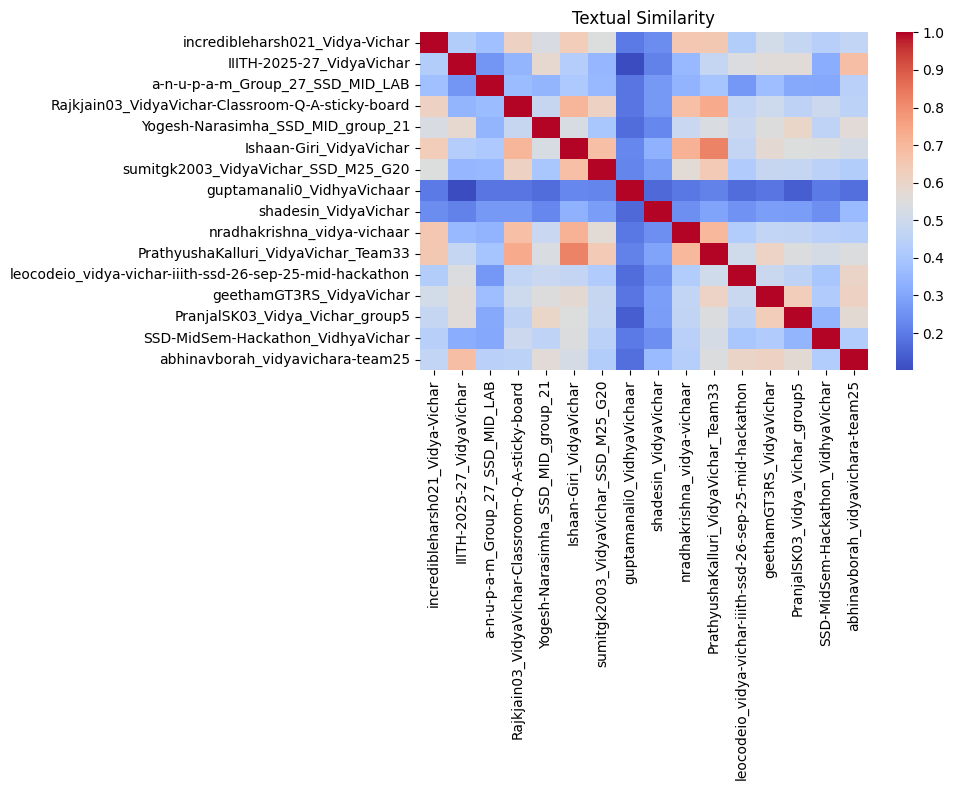

,incredibleharsh021_Vidya-Vichar,IIITH-2025-27_VidyaVichar,a-n-u-p-a-m_Group_27_SSD_MID_LAB,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,Yogesh-Narasimha_SSD_MID_group_21,Ishaan-Giri_VidyaVichar,sumitgk2003_VidyaVichar_SSD_M25_G20,guptamanali0_VidhyaVichaar,shadesin_VidyaVichar,nradhakrishna_vidya-vichaar,PrathyushaKalluri_VidyaVichar_Team33,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon,geethamGT3RS_VidyaVichar,PranjalSK03_Vidya_Vichar_group5,SSD-MidSem-Hackathon_VidhyaVichar,abhinavborah_vidyavichara-team25
incredibleharsh021_Vidya-Vichar,1.000000,0.427625,0.376461,0.613830,0.533868,0.631519,0.547370,0.196718,0.240584,0.653001,0.652269,0.424357,0.513163,0.475588,0.438122,0.466765
IIITH-2025-27_VidyaVichar,0.427625,1.000000,0.260725,0.340965,0.584132,0.429876,0.349205,0.101180,0.215373,0.355359,0.476155,0.542950,0.561712,0.564410,0.319552,0.683254
a-n-u-p-a-m_Group_27_SSD_MID_LAB,0.376461,0.260725,1.000000,0.362546,0.340870,0.408053,0.355425,0.187703,0.267447,0.339020,0.390963,0.265738,0.368677,0.310032,0.306848,0.444978
Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,0.613830,0.340965,0.362546,1.000000,0.477074,0.706713,0.613211,0.186362,0.266208,0.677232,0.736203,0.467957,0.500455,0.453795,0.492757,0.452210
Yogesh-Narasimha_SSD_MID_group_21,0.533868,0.584132,0.340870,0.477074,1.000000,0.531862,0.402855,0.168431,0.227118,0.484309,0.537147,0.486721,0.550714,0.596907,0.459029,0.567131
Ishaan-Giri_VidyaVichar,0.631519,0.429876,0.408053,0.706713,0.531862,1.000000,0.678172,0.224831,0.330216,0.716736,0.821750,0.470126,0.576510,0.547248,0.546222,0.524737
sumitgk2003_VidyaVichar_SSD_M25_G20,0.547370,0.349205,0.355425,0.613211,0.402855,0.678172,1.000000,0.222242,0.277219,0.568898,0.642813,0.420483,0.477068,0.474152,0.447963,0.426157
guptamanali0_VidhyaVichaar,0.196718,0.101180,0.187703,0.186362,0.168431,0.224831,0.222242,1.000000,0.162011,0.192980,0.215247,0.170062,0.187817,0.138421,0.197045,0.173267
shadesin_VidyaVichar,0.240584,0.215373,0.267447,0.266208,0.227118,0.330216,0.277219,0.162011,1.000000,0.244705,0.296019,0.253847,0.282671,0.277433,0.242447,0.360597
nradhakrishna_vidya-vichaar,0.653001,0.355359,0.339020,0.677232,0.484309,0.716736,0.568898,0.192980,0.244705,1.000000,0.699221,0.421025,0.467753,0.465342,0.445010,0.432567


100%|████████████████████████████████████████████████| 16/16 [00:00<00:00, 20.32it/s]



 2__ Level 2: Structural Similarity ...done


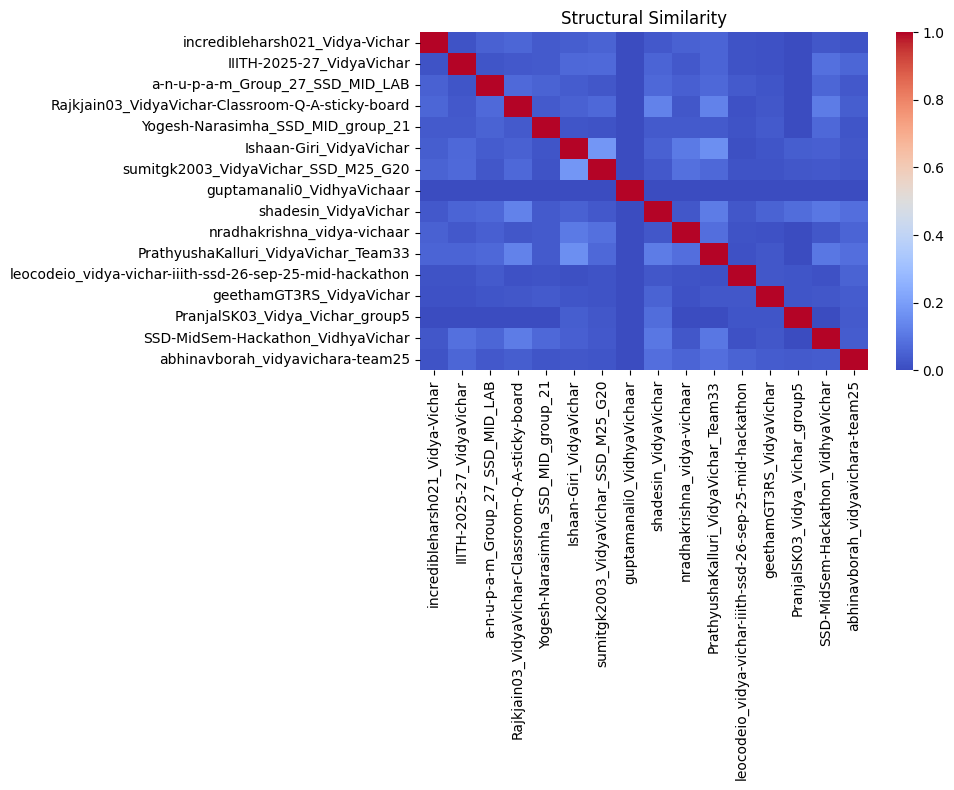

,incredibleharsh021_Vidya-Vichar,IIITH-2025-27_VidyaVichar,a-n-u-p-a-m_Group_27_SSD_MID_LAB,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,Yogesh-Narasimha_SSD_MID_group_21,Ishaan-Giri_VidyaVichar,sumitgk2003_VidyaVichar_SSD_M25_G20,guptamanali0_VidhyaVichaar,shadesin_VidyaVichar,nradhakrishna_vidya-vichaar,PrathyushaKalluri_VidyaVichar_Team33,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon,geethamGT3RS_VidyaVichar,PranjalSK03_Vidya_Vichar_group5,SSD-MidSem-Hackathon_VidhyaVichar,abhinavborah_vidyavichara-team25
incredibleharsh021_Vidya-Vichar,1.000000,0.015873,0.047619,0.058824,0.035088,0.042553,0.051724,0.000852,0.027778,0.046875,0.057143,0.018182,0.015152,0.000000,0.027027,0.018868
IIITH-2025-27_VidyaVichar,0.015873,1.000000,0.023256,0.028571,0.035088,0.065217,0.070175,0.001991,0.057143,0.030769,0.057143,0.018182,0.015152,0.000000,0.085714,0.058824
a-n-u-p-a-m_Group_27_SSD_MID_LAB,0.047619,0.023256,1.000000,0.066667,0.054054,0.035714,0.025000,0.000571,0.062500,0.044444,0.062500,0.033708,0.021739,0.000000,0.058824,0.030303
Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,0.058824,0.028571,0.066667,1.000000,0.033333,0.050000,0.064516,0.000286,0.125000,0.026316,0.125000,0.012048,0.026316,0.000000,0.111111,0.040000
Yogesh-Narasimha_SSD_MID_group_21,0.035088,0.035088,0.054054,0.033333,1.000000,0.023256,0.018182,0.000284,0.032258,0.033333,0.032258,0.019048,0.033333,0.000000,0.064516,0.020833
Ishaan-Giri_VidyaVichar,0.042553,0.065217,0.035714,0.050000,0.023256,1.000000,0.179487,0.003146,0.047619,0.106383,0.157895,0.010417,0.019608,0.040000,0.045455,0.026316
sumitgk2003_VidyaVichar_SSD_M25_G20,0.051724,0.070175,0.025000,0.064516,0.018182,0.179487,1.000000,0.003135,0.030303,0.084746,0.062500,0.018692,0.015873,0.027027,0.029412,0.020000
guptamanali0_VidhyaVichaar,0.000852,0.001991,0.000571,0.000286,0.000284,0.003146,0.003135,1.000000,0.000859,0.001705,0.000859,0.001683,0.001136,0.000858,0.000572,0.000570
shadesin_VidyaVichar,0.027778,0.057143,0.062500,0.125000,0.032258,0.047619,0.030303,0.000859,1.000000,0.025641,0.111111,0.024096,0.052632,0.076923,0.100000,0.080000
nradhakrishna_vidya-vichaar,0.046875,0.030769,0.044444,0.026316,0.033333,0.106383,0.084746,0.001705,0.025641,1.000000,0.081081,0.017699,0.014493,0.000000,0.025000,0.055556


Batches: 100%|█████████████████████████████████████████| 1/1 [01:20<00:00, 80.21s/it]



 3__ Level 3: Semantic Similarity (MiniLM) ... done 


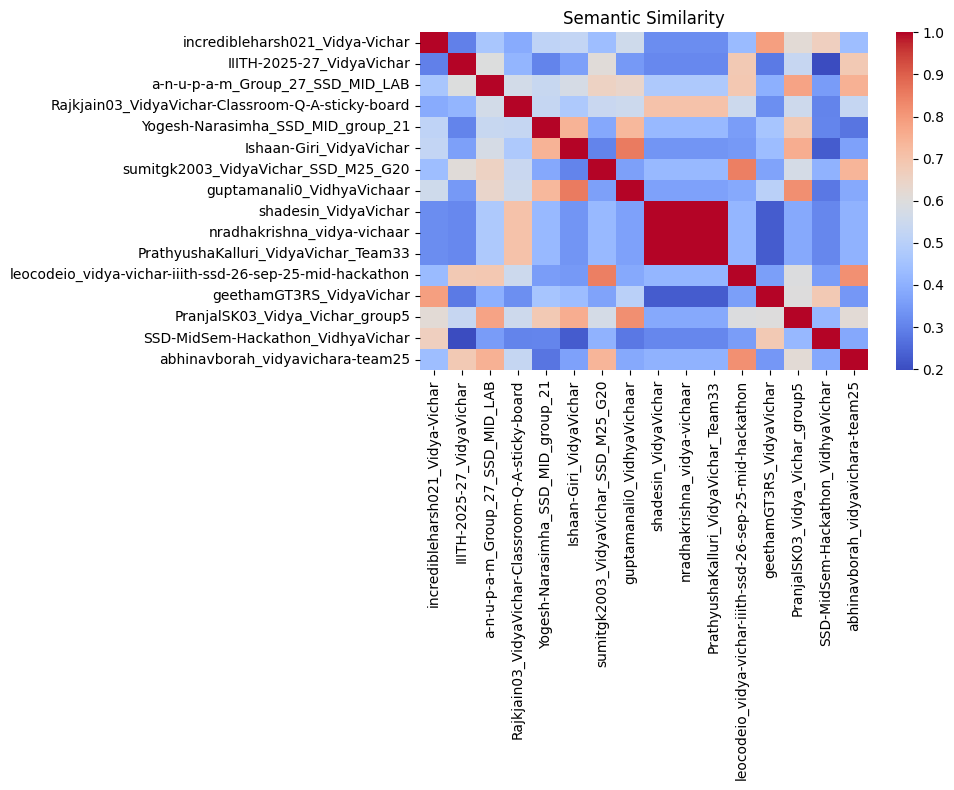

,incredibleharsh021_Vidya-Vichar,IIITH-2025-27_VidyaVichar,a-n-u-p-a-m_Group_27_SSD_MID_LAB,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,Yogesh-Narasimha_SSD_MID_group_21,Ishaan-Giri_VidyaVichar,sumitgk2003_VidyaVichar_SSD_M25_G20,guptamanali0_VidhyaVichaar,shadesin_VidyaVichar,nradhakrishna_vidya-vichaar,PrathyushaKalluri_VidyaVichar_Team33,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon,geethamGT3RS_VidyaVichar,PranjalSK03_Vidya_Vichar_group5,SSD-MidSem-Hackathon_VidhyaVichar,abhinavborah_vidyavichara-team25
incredibleharsh021_Vidya-Vichar,1.000000,0.295061,0.463206,0.386010,0.515523,0.525190,0.438438,0.555952,0.321213,0.321213,0.321213,0.427108,0.788711,0.617579,0.663634,0.436792
IIITH-2025-27_VidyaVichar,0.295061,1.000000,0.596580,0.411380,0.302469,0.361676,0.609662,0.345314,0.312967,0.312967,0.312967,0.685355,0.283850,0.535308,0.197602,0.686362
a-n-u-p-a-m_Group_27_SSD_MID_LAB,0.463206,0.596580,1.000000,0.566803,0.537451,0.576148,0.653926,0.638603,0.473754,0.473754,0.473754,0.689513,0.400229,0.777573,0.354022,0.748089
Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,0.386010,0.411380,0.566803,1.000000,0.532159,0.475456,0.541844,0.549561,0.703276,0.703276,0.703276,0.549846,0.324088,0.553549,0.302476,0.531918
Yogesh-Narasimha_SSD_MID_group_21,0.515523,0.302469,0.537451,0.532159,1.000000,0.745790,0.379927,0.732531,0.424368,0.424368,0.424368,0.354715,0.459453,0.683831,0.304600,0.274651
Ishaan-Giri_VidyaVichar,0.525190,0.361676,0.576148,0.475456,0.745790,1.000000,0.303786,0.855037,0.338048,0.338048,0.338048,0.347358,0.433613,0.757884,0.226988,0.365987
sumitgk2003_VidyaVichar_SSD_M25_G20,0.438438,0.609662,0.653926,0.541844,0.379927,0.303786,1.000000,0.363381,0.424466,0.424466,0.424466,0.846718,0.367691,0.571434,0.406277,0.739808
guptamanali0_VidhyaVichaar,0.555952,0.345314,0.638603,0.549561,0.732531,0.855037,0.363381,1.000000,0.366304,0.366304,0.366304,0.383710,0.502652,0.819981,0.279941,0.385139
shadesin_VidyaVichar,0.321213,0.312967,0.473754,0.703276,0.424368,0.338048,0.424466,0.366304,1.000000,1.000000,1.000000,0.414202,0.227739,0.382721,0.310036,0.407501
nradhakrishna_vidya-vichaar,0.321213,0.312967,0.473754,0.703276,0.424368,0.338048,0.424466,0.366304,1.000000,1.000000,1.000000,0.414202,0.227739,0.382721,0.310036,0.407501



 --> All results saved in: /home/lalithamsh-k/ssdpy3/Q1/results


In [2]:
import os, re, json, numpy as np, pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import esprima
import seaborn as sns
import matplotlib.pyplot as plt

BASE_DIR = "/home/lalithamsh-k/ssdpy3/Q1/repos" #rename for clarity         <------CHANGE HERE
OUTPUT_DIR = "/home/lalithamsh-k/ssdpy3/Q1/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def collect_code(repo_path):
    code_texts = []
    for root, _, files in os.walk(repo_path):
        for f in files:
            if f.endswith((".js", ".jsx", ".ts")):
                try:
                    with open(os.path.join(root, f), encoding="utf-8", errors="ignore") as fh:
                        code_texts.append(fh.read())
                except Exception:
                    pass
    return "\n".join(code_texts)


# 1 Textual Similarity (TF-IDF + Cosine)

def textual_similarity(corpus, names):
    vectorizer = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1,2))
    X = vectorizer.fit_transform(corpus)
    sim_matrix = cosine_similarity(X)
    df = pd.DataFrame(sim_matrix, index=names, columns=names)
    df.to_csv(os.path.join(OUTPUT_DIR, "similarity_textual.csv"))
    print("\n 1__ Level 1: Textual Similarity ...done")
    return df

# 2 – Structural Similarity (AST + Jaccard)

def extract_structure(code):
    try:
        parsed = esprima.parseScript(code)
        elements = []
        def walk(node):
            if isinstance(node, list):
                for n in node:
                    walk(n)
            elif hasattr(node, "type"):
                elements.append(node.type)
                for child_name in node.__dict__:
                    walk(getattr(node, child_name))
        walk(parsed)
        return set(elements)
    except Exception:
        # fallback if parsing fails
        funcs = re.findall(r'function\s+\w+|\bclass\s+\w+', code)
        return set(funcs)

def jaccard(a, b):
    if not a and not b: return 1.0
    return len(a & b) / len(a | b)

def structural_similarity(corpus, names):
    structures = [extract_structure(c) for c in tqdm(corpus)]
    n = len(structures)
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sim[i,j] = jaccard(structures[i], structures[j])
    df = pd.DataFrame(sim, index=names, columns=names)
    df.to_csv(os.path.join(OUTPUT_DIR, "similarity_structural.csv"))
    print("\n 2__ Level 2: Structural Similarity ...done")
    return df

# 3 – semantic analysis (sentence-transformers(MiniLM) codebert too heavy for 4 gb vm

def semantic_similarity(corpus, names):
    model = SentenceTransformer("all-MiniLM-L6-v2")  # codebert not working
    embeddings = model.encode(corpus, convert_to_tensor=False, show_progress_bar=True)
    sim = cosine_similarity(embeddings)
    df = pd.DataFrame(sim, index=names, columns=names)
    df.to_csv(os.path.join(OUTPUT_DIR, "similarity_semantic.csv"))
    print("\n 3__ Level 3: Semantic Similarity (MiniLM) ... done ")
    return df


#  Plot Heatmap
def plot_heatmap(df, title, fname):
    plt.figure(figsize=(10,8))
    sns.heatmap(df, cmap="coolwarm", xticklabels=True, yticklabels=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, fname))
    plt.show()
    plt.close()

    
def main():
    repos = [os.path.join(BASE_DIR, d) for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
    names = [os.path.basename(r) for r in repos]
    corpus = [collect_code(r) for r in tqdm(repos, desc="Reading repos")]

    # Textual
    df_text = textual_similarity(corpus, names)
    plot_heatmap(df_text, "Textual Similarity", "heatmap_textual.png")
    display(df_text)
    

    # Structural
    df_struct = structural_similarity(corpus, names)
    plot_heatmap(df_struct, "Structural Similarity", "heatmap_structural.png")
    display(df_struct)
    
            
    # Semantic
    df_sem = semantic_similarity(corpus, names)
    plot_heatmap(df_sem, "Semantic Similarity", "heatmap_semantic.png")
    display(df_sem)
    
    print(f"\n --> All results saved in: {OUTPUT_DIR}")
       
if __name__ == "__main__":
    main()


,incredibleharsh021_Vidya-Vichar,IIITH-2025-27_VidyaVichar,a-n-u-p-a-m_Group_27_SSD_MID_LAB,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,Yogesh-Narasimha_SSD_MID_group_21,Ishaan-Giri_VidyaVichar,sumitgk2003_VidyaVichar_SSD_M25_G20,guptamanali0_VidhyaVichaar,shadesin_VidyaVichar,nradhakrishna_vidya-vichaar,PrathyushaKalluri_VidyaVichar_Team33,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid-hackathon,geethamGT3RS_VidyaVichar,PranjalSK03_Vidya_Vichar_group5,SSD-MidSem-Hackathon_VidhyaVichar,abhinavborah_vidyavichara-team25
incredibleharsh021_Vidya-Vichar,1.000000,0.175918,0.145802,0.257633,0.256233,0.302824,0.225391,0.119408,0.072490,0.270968,0.269821,0.153611,0.311126,0.232629,0.247066,0.194034
IIITH-2025-27_VidyaVichar,0.121331,1.000000,0.120359,0.118660,0.221665,0.165561,0.180066,0.018840,0.070077,0.114863,0.177918,0.289907,0.204287,0.247210,0.095314,0.383584
a-n-u-p-a-m_Group_27_SSD_MID_LAB,0.156257,0.179751,1.000000,0.189072,0.177030,0.197952,0.177854,0.138240,0.138719,0.153876,0.178278,0.163796,0.141995,0.207606,0.117217,0.273903
Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,0.257037,0.171424,0.178643,1.000000,0.232799,0.331746,0.294091,0.112797,0.222590,0.373701,0.438693,0.209779,0.189010,0.201765,0.217897,0.221679
Yogesh-Narasimha_SSD_MID_group_21,0.244469,0.255101,0.153837,0.222110,1.000000,0.300731,0.120800,0.155638,0.094571,0.208654,0.227903,0.161830,0.251630,0.310419,0.182986,0.198674


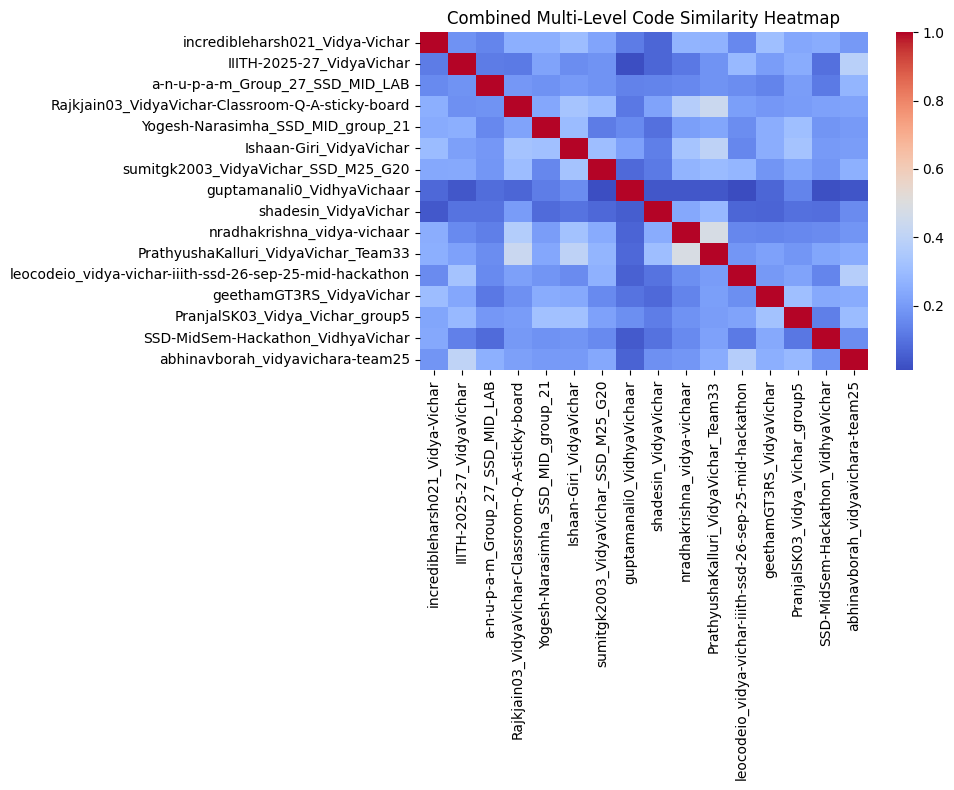

,Project_A,Project_B,Similarity
154,nradhakrishna_vidya-vichaar,PrathyushaKalluri_VidyaVichar_Team33,0.483351
58,Rajkjain03_VidyaVichar-Classroom-Q-A-sticky-board,PrathyushaKalluri_VidyaVichar_Team33,0.435233
31,IIITH-2025-27_VidyaVichar,abhinavborah_vidyavichara-team25,0.404393
90,Ishaan-Giri_VidyaVichar,PrathyushaKalluri_VidyaVichar_Team33,0.398849
191,leocodeio_vidya-vichar-iiith-ssd-26-sep-25-mid...,abhinavborah_vidyavichara-team25,0.372009


,Project_A,Project_B,Similarity
103,sumitgk2003_VidyaVichar_SSD_M25_G20,guptamanali0_VidhyaVichaar,0.017120
23,IIITH-2025-27_VidyaVichar,guptamanali0_VidhyaVichaar,0.037614
8,incredibleharsh021_Vidya-Vichar,shadesin_VidyaVichar,0.040374
126,guptamanali0_VidhyaVichaar,SSD-MidSem-Hackathon_VidhyaVichar,0.042778
120,guptamanali0_VidhyaVichaar,shadesin_VidyaVichar,0.051289


 text vs struct: 0.31655561719326736
 text vs sem: -0.037867422527193294
 struct vs sem: -0.12989629614079895


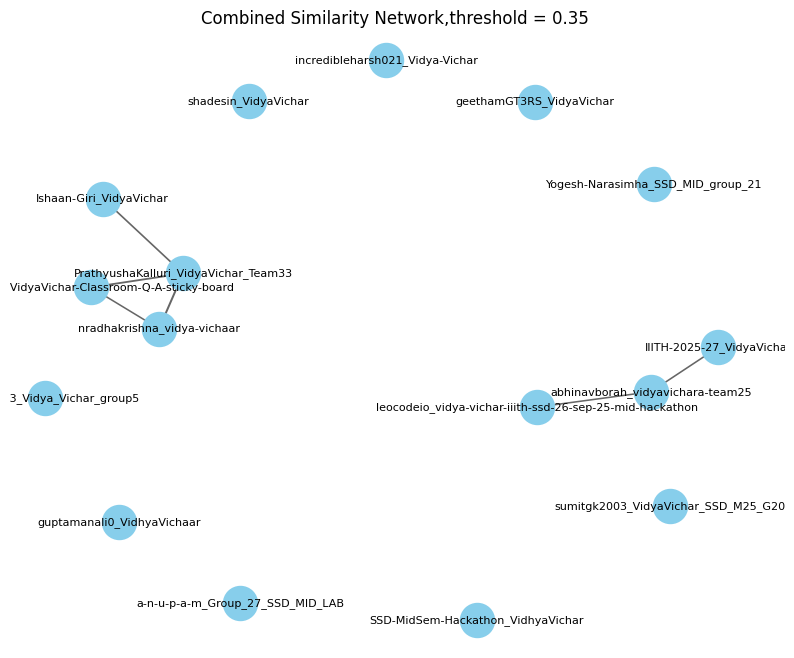

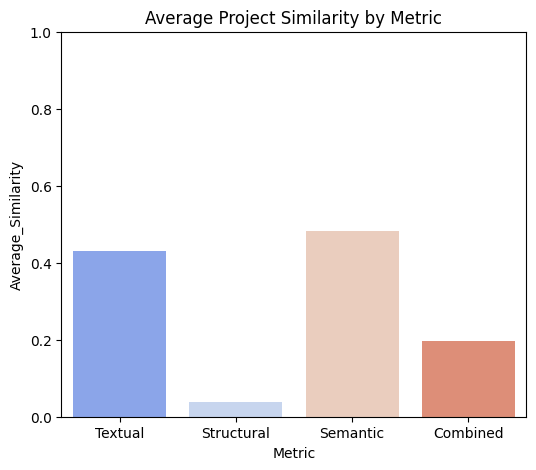

,Metric,Average_Similarity
0,Textual,0.431354
1,Structural,0.037368
2,Semantic,0.481813
3,Combined,0.196952


In [27]:

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import numpy as np




OUTPUT_DIR = "/home/lalithamsh-k/ssdpy3/Q1/results"          #<--------CHANGE HERE
# make them scale the same
scaler = MinMaxScaler()

def normalize(df):
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

textual_sim_df = pd.read_csv("/home/lalithamsh-k/ssdpy3/Q1/results/similarity_textual.csv", index_col=0)   #<----CHANGE THESE 3 
structural_sim_df = pd.read_csv("/home/lalithamsh-k/ssdpy3/Q1/results/similarity_structural.csv", index_col=0) #   while running on
semantic_sim_df = pd.read_csv("/home/lalithamsh-k/ssdpy3/Q1/results/similarity_semantic.csv", index_col=0) #       different machine 

textual_norm = normalize(textual_sim_df)
structural_norm = normalize(structural_sim_df)
semantic_norm = normalize(semantic_sim_df)
#  Multiplicative strict match
#combined_df = textual_norm * structural_norm * semantic_norm

# Weighted average balanced
combined_df = (0.4 * textual_norm + 0.4 * structural_norm + 0.2 * semantic_norm)


display(combined_df.head())

# --- Plot combined heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(combined_df, cmap="coolwarm", xticklabels=True, yticklabels=True)
plt.title("Combined Multi-Level Code Similarity Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "similarity_matrix.jpg"))
plt.show()

# Flatten the matrix into pairs
pairs = combined_df.unstack().reset_index()
pairs.columns = ['Project_A', 'Project_B', 'Similarity']

# Remove identical pairs (A vs A)
pairs = pairs[pairs['Project_A'] != pairs['Project_B']]

# Sort pairs alphabetically so A–B and B–A are treated the same
pairs['Pair'] = pairs.apply(lambda x: tuple(sorted([x['Project_A'], x['Project_B']])), axis=1)

# Drop duplicates
pairs = pairs.drop_duplicates('Pair').drop(columns='Pair')

# Sort by similarity
top5 = pairs.sort_values(by='Similarity', ascending=False).head(5)
bottom5 = pairs.sort_values(by='Similarity', ascending=True).head(5)

display(top5)
display(bottom5)


#for weights calculation

from scipy.stats import spearmanr

def matrix_to_vector_upper(df):
    n = df.shape[0]
    ix = np.triu_indices(n, k=1)
    return df.values[ix]

v1 = matrix_to_vector_upper(textual_sim_df)
v2 = matrix_to_vector_upper(structural_sim_df)
v3 = matrix_to_vector_upper(semantic_sim_df)

print(" text vs struct:", spearmanr(v1, v2).correlation)
print(" text vs sem:", spearmanr(v1, v3).correlation)
print(" struct vs sem:", spearmanr(v2, v3).correlation)





def plot_similarity_network(sim_df, threshold=0.40, title="Project Similarity Network"):
    """
    Creates a network graph where edges connect highly similar projects.
    threshold: similarity value above which we connect nodes.
    """
    G = nx.Graph()
    
    # Add nodes
    for project in sim_df.columns:
        G.add_node(project)
    
    # Add edges for strong similarities
    for i, p1 in enumerate(sim_df.columns):
        for j, p2 in enumerate(sim_df.columns):
            if i < j and sim_df.iloc[i, j] >= threshold:
                G.add_edge(p1, p2, weight=sim_df.iloc[i, j])
    
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.8, iterations=100,seed=42)  # layout for spacing
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, width=[3*w for w in weights], alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8)
    
    plt.title(title)
    plt.axis('off')
    plt.savefig("/home/lalithamsh-k/ssdpy3/Q1/results/network.png", format='jpg', dpi=300, bbox_inches='tight')
    plt.show()


plot_similarity_network(combined_df, threshold=0.35, title="Combined Similarity Network,threshold = 0.35 ")



def avg_similarity(df):
    vals = df.values
    n = len(df)
    return (np.sum(vals) - np.trace(vals)) / (n*(n-1))

avg_scores = {
    "Textual": avg_similarity(textual_sim_df),
    "Structural": avg_similarity(structural_sim_df),
    "Semantic": avg_similarity(semantic_sim_df),
    "Combined": avg_similarity(combined_df)
}

avg_df = pd.DataFrame(list(avg_scores.items()), columns=["Metric", "Average_Similarity"])

# Plot <---shows how similar the average projects are across each metric type
plt.figure(figsize=(6,5))
sns.barplot(
    x="Metric", 
    y="Average_Similarity", 
    data=avg_df, 
    hue="Metric", 
    palette="coolwarm", 
    legend=False 
)
plt.title("Average Project Similarity by Metric")
plt.ylim(0, 1)
plt.show()

display(avg_df)